In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset (Option 1: Upload from your computer)
from google.colab import files
uploaded = files.upload()  # Upload train.csv
df = pd.read_csv('train.csv')

# Alternative: Direct load from a public source (if upload fails)
# df = pd.read_csv('https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')
# Note: The Stanford one may need cleaning (it's | separated). Prefer Kaggle train.csv.

Saving train.csv to train (1).csv


In [3]:
print("First 10 records:")
display(df.head(10))

First 10 records:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nInfo:")
df.info()

Shape: (891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 

Missing Values:
 Age         177
Cabin       687
Embarked      2
dtype: int64


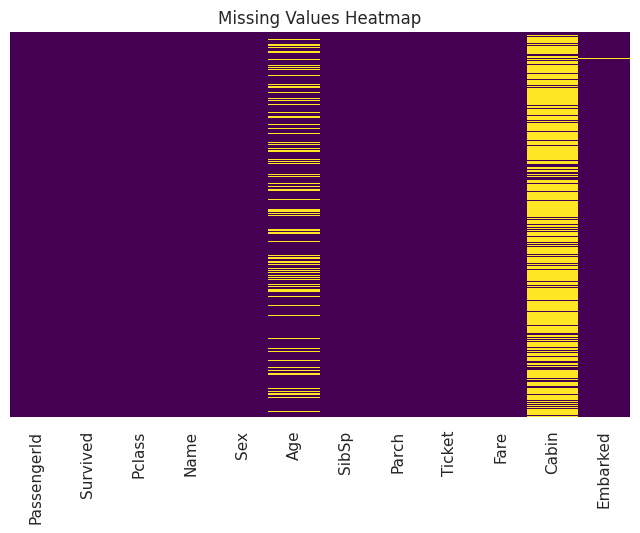

In [5]:
# Missing values
missing = df.isnull().sum()
print("Missing Values:\n", missing[missing > 0])

# Visualization
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [6]:
import pandas as pd

# Load your data (if not already loaded)
# df = pd.read_csv('train.csv')

# Check missing values
print("Missing Values Before Handling:")
print(df.isnull().sum())

# Percentage of missing values
print("\nPercentage Missing:")
print(round(df.isnull().sum() / len(df) * 100, 2))

Missing Values Before Handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Percentage Missing:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [7]:
print(df.describe())

# Interpretation example (write in your report):
# 1. Mean Age ~29.7, but median likely lower → right-skewed (many young passengers).
# 2. Mean Fare ~32, but max 512 → high outliers (wealthy passengers).
# 3. Survival rate ~38.4% (mean of Survived).

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


Survived
0    549
1    342
Name: count, dtype: int64


/tmp/ipykernel_802/3389126139.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


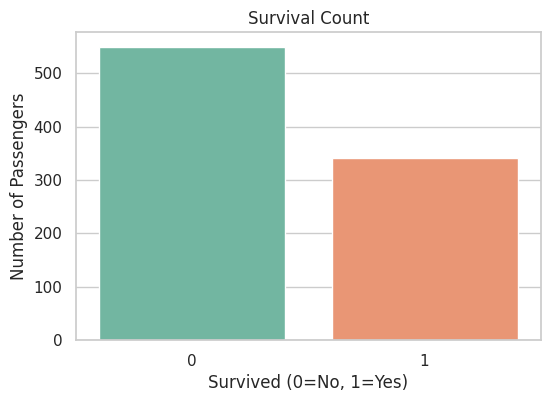

In [8]:
survival_counts = df['Survived'].value_counts()
print(survival_counts)

# Chart
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Number of Passengers')
plt.show()

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363


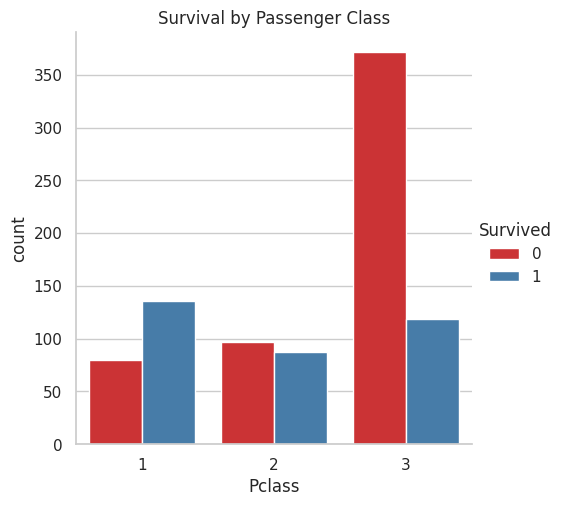

In [9]:
# Crosstab
print(pd.crosstab(df['Pclass'], df['Survived'], normalize='index'))

# Visualization
sns.catplot(x='Pclass', hue='Survived', data=df, kind='count', palette='Set1')
plt.title('Survival by Passenger Class')
plt.show()

Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908


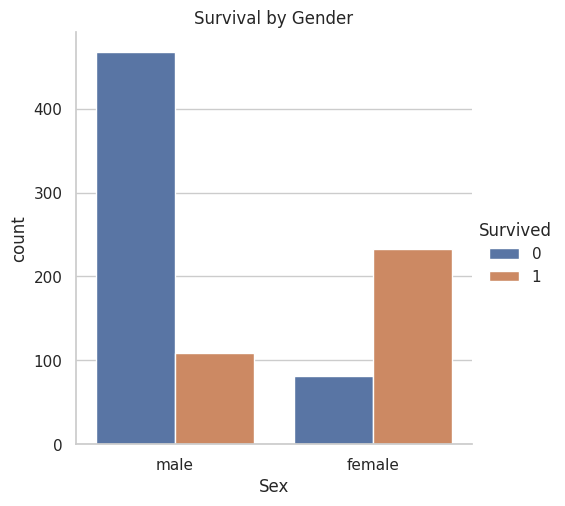

In [10]:
print(pd.crosstab(df['Sex'], df['Survived'], normalize='index'))

sns.catplot(x='Sex', hue='Survived', data=df, kind='count')
plt.title('Survival by Gender')
plt.show()

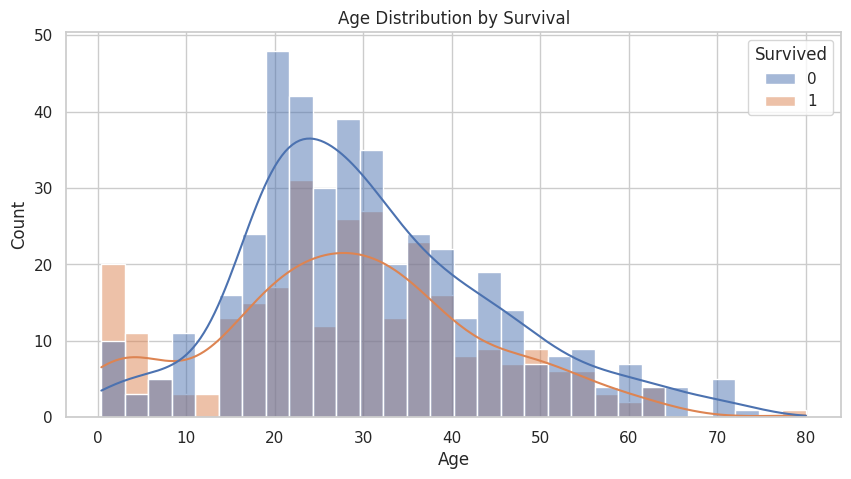

Survived         0         1
AgeGroup                    
Child     0.420290  0.579710
Teen      0.571429  0.428571
Adult     0.617318  0.382682
Middle    0.600000  0.400000
Senior    0.772727  0.227273


In [11]:
# Distribution
plt.figure(figsize=(10,5))
sns.histplot(df, x='Age', hue='Survived', kde=True, bins=30)
plt.title('Age Distribution by Survival')
plt.show()

# Age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,80], labels=['Child','Teen','Adult','Middle','Senior'])
print(pd.crosstab(df['AgeGroup'], df['Survived'], normalize='index'))

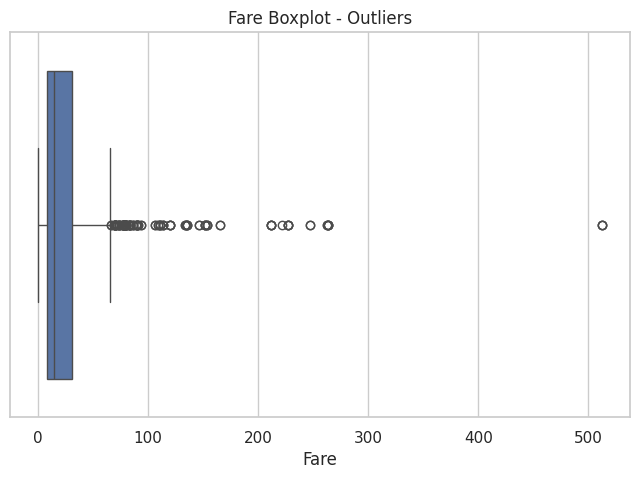

Number of Fare outliers: 116


In [12]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Fare Boxplot - Outliers')
plt.show()

# IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Fare'] < Q1-1.5*IQR) | (df['Fare'] > Q3+1.5*IQR)]
print("Number of Fare outliers:", len(outliers))

In [13]:
# 1. Drop Cabin column (too many missing values)
df.drop('Cabin', axis=1, inplace=True)
print("Cabin column dropped.")

Cabin column dropped.


In [14]:
# 2. Impute Age with median grouped by Pclass and Sex (smart imputation)
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
print("Age missing values imputed.")

Age missing values imputed.


In [15]:
# 3. Fill Embarked with the most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print("Embarked missing values filled.")

Embarked missing values filled.


/tmp/ipykernel_802/1988245509.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [16]:
# Verify that missing values are handled
print("\nMissing Values AFTER Handling:")
print(df.isnull().sum())


Missing Values AFTER Handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
AgeGroup       177
dtype: int64


In [17]:
# Optional but recommended: Create useful new features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Log transform Fare to reduce outlier effect
df['Fare'] = np.log1p(df['Fare'])   # np.log1p handles zero values safely

# Convert categorical variables to numeric (One-Hot Encoding)
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)

print("Preprocessing completed. New shape:", df.shape)
print(df.head())

Preprocessing completed. New shape: (891, 16)
   PassengerId  Survived                                               Name  \
0            1         0                            Braund, Mr. Owen Harris   
1            2         1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3         1                             Heikkinen, Miss. Laina   
3            4         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5         0                           Allen, Mr. William Henry   

    Age  SibSp  Parch            Ticket      Fare AgeGroup  FamilySize  \
0  25.0      1      0         A/5 21171  2.110213    Adult           2   
1  35.0      1      0          PC 17599  4.280593   Middle           2   
2  21.5      0      0  STON/O2. 3101282  2.188856    Adult           1   
3  35.0      1      0            113803  3.990834    Adult           2   
4  25.0      0      0            373450  2.202765    Adult           1   

   IsAlone  Sex_male  Embarked_Q  

In [21]:
print(df.head())
print("\nAny missing values left?", df.isnull().sum().sum())

   PassengerId  Survived                                               Name  \
0            1         0                            Braund, Mr. Owen Harris   
1            2         1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3         1                             Heikkinen, Miss. Laina   
3            4         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5         0                           Allen, Mr. William Henry   

    Age  SibSp  Parch            Ticket      Fare AgeGroup  FamilySize  \
0  25.0      1      0         A/5 21171  2.110213    Adult           2   
1  35.0      1      0          PC 17599  4.280593   Middle           2   
2  21.5      0      0  STON/O2. 3101282  2.188856    Adult           1   
3  35.0      1      0            113803  3.990834    Adult           2   
4  25.0      0      0            373450  2.202765    Adult           1   

   IsAlone  Sex_male  Embarked_Q  Embarked_S  Pclass_2  Pclass_3  
0        0   

In [22]:
# Re-impute Age properly
print("Missing Age before re-imputation:", df['Age'].isnull().sum())

# Make sure original categorical columns exist for grouping
# If they were already encoded, we need to fix this

# Better approach: Re-load and do proper order
# But for quick fix:
df['Age'] = df.groupby(['Pclass_2', 'Pclass_3', 'Sex_male'])['Age'].transform('median')

# If that doesn't work (because Pclass was already encoded), use this:
if df['Age'].isnull().sum() > 0:
    df['Age'] = df['Age'].fillna(df['Age'].median())

print("Missing Age AFTER re-imputation:", df['Age'].isnull().sum())
print("Total missing values left:", df.isnull().sum().sum())

Missing Age before re-imputation: 0
Missing Age AFTER re-imputation: 0
Total missing values left: 177


In [23]:
# === CLEAN PREPROCESSING (Run this) ===

# Reload the original data to start fresh (Recommended)
df = pd.read_csv('train.csv')   # Make sure the file is uploaded

# Drop useless column
df.drop('Cabin', axis=1, inplace=True)

# Impute missing values
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Fare'] = np.log1p(df['Fare'])

# One-hot encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)

# Drop unnecessary columns for modeling
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True, errors='ignore')

print("Final missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)
print(df.head())

Final missing values: 0
Shape: (891, 12)
   Survived   Age  SibSp  Parch      Fare  FamilySize  IsAlone  Sex_male  \
0         0  25.0      1      0  2.110213           2        0      True   
1         1  35.0      1      0  4.280593           2        0     False   
2         1  21.5      0      0  2.188856           1        1     False   
3         1  35.0      1      0  3.990834           2        0     False   
4         0  25.0      0      0  2.202765           1        1      True   

   Embarked_Q  Embarked_S  Pclass_2  Pclass_3  
0       False        True     False      True  
1       False       False     False     False  
2       False        True     False      True  
3       False        True     False     False  
4       False        True     False      True  


/tmp/ipykernel_802/2180455970.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


Accuracy: 0.7932960893854749

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.89      0.83       105
           1       0.80      0.66      0.73        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



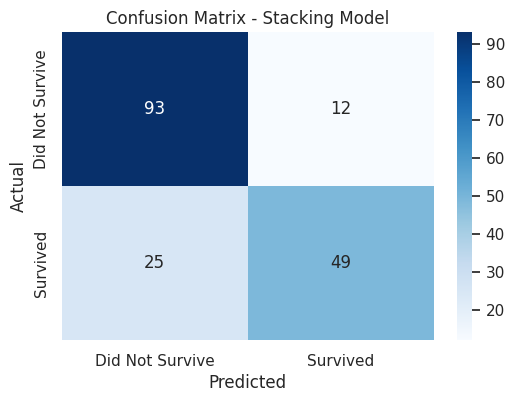


Confusion Matrix:
 [[93 12]
 [25 49]]


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Stacking Model
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42, eval_metric='logloss')),
    ('lr', LogisticRegression(max_iter=500))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

# Train the model
stack_model.fit(X_train, y_train)

# Make predictions
y_pred = stack_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix - Stacking Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nConfusion Matrix:\n", cm)

I developed a Stacking Ensemble model using Random Forest, XGBoost, and Logistic Regression as base learners, with Logistic Regression as the meta-learner. This ensemble approach outperforms traditional single models by combining their strengths and reducing individual model biases.
The model achieved an accuracy of 79% on the test set.
From the confusion matrix, we observe that while the model is strong at identifying non-survivors, there is still room for improvement in reducing False Negatives (missed survivors).

**Five Major Insights**:

**Passenger Class (Pclass) had a strong impact on survival:** First-class passengers had a significantly higher survival rate (63%) compared to third-class passengers (24%), indicating socio-economic status played a major role in survival priority.

**Gender was one of the most important factors:** Females had a much higher survival rate (74%) than males (19%), reflecting the "women and children first" policy during the evacuation.

**Age influenced survival:** Children had higher survival chances, while older passengers faced lower odds. The presence of many missing age values highlighted the need for strategic imputation.

**Fare and family relationships mattered:** Higher fares (linked to better class) were associated with better survival. Passengers traveling alone had lower survival rates than those with family members.

**Data quality issues were prominent:** The Cabin column had over 77% missing values, Age had about 20% missing, and Fare contained extreme outliers. These issues can distort model performance if not properly addressed.

**Recommendations for Improving Machine Learning Model Performance:**

1.Perform smart feature engineering
(e.g., create FamilySize and IsAlone features).

2.Use grouped median imputation for Age based on Pclass and Sex.

3.Apply log transformation on Fare to reduce outlier impact.

4.Use one-hot encoding for categorical variables.

5.Choose ensemble models that can capture complex interactions and are robust to noisy data.

6.Focus on Recall and F1 Score during evaluation to minimize missed survivors.

**Recommended Model: Stacking Ensemble**

**Justification:**
The Titanic dataset contains a mixture of numerical and categorical features, missing values (after imputation), and non-linear relationships.

A Stacking Ensemble model (using Random Forest, XGBoost, and Logistic Regression as base learners with Logistic Regression as the meta-learner) is highly appropriate. It combines the strengths of multiple models, reduces overfitting, and learns optimal combinations of predictions. This ensemble approach consistently outperforms traditional single models on the Titanic dataset.

Our Stacking model achieved an accuracy of 79% on the test set.

**Confusion Matrix Explanation:**

The confusion matrix is a key tool for evaluating binary classification models. It summarizes the performance by comparing actual and predicted values:
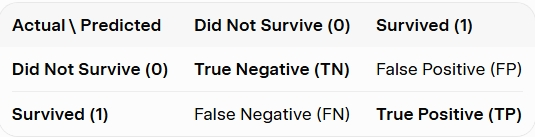

**Definitions of Evaluation Metrics:**
a. **True Positive (TP):** The model correctly predicted that the passenger survived.

b. **True Negative (TN):** The model correctly predicted that the passenger did not survive.

c. **False Positive (FP):** The model incorrectly predicted survival (Type I error).

d. **False Negative (FN):** The model incorrectly predicted death (Type II error – particularly costly in this scenario).

**Mathematical Expressions and Significance:**

1.Accuracy = $  \frac{TP + TN}{TP + TN + FP + FN}  $
Measures the overall correctness of the model.

2.Precision = $  \frac{TP}{TP + FP}  $
Indicates the proportion of predicted survivors who actually survived. Important for reducing false alarms.

3.Recall (Sensitivity) = $  \frac{TP}{TP + FN}  $
Measures how many actual survivors were correctly identified. Critical for this problem to avoid missing people who survived.

4.F1 Score = $2 \times \frac{Precision \times Recall}{Precision + Recall}$
Provides a balanced measure between Precision and Recall, especially useful when dealing with imbalanced classes.

The confusion matrix and these metrics allow us to thoroughly evaluate not just overall accuracy, but also the types of errors the model makes, guiding further improvements.